In [ ]:
import kagglehub
import pandas as pd
import os
import re
import nltk
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download resource untuk NLTK
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Fungsi untuk menormalisasi teks mentah.
    Tahapan: Case Folding -> Hapus URL -> Hapus Mention/Hashtag -> 
    Hapus Tanda Baca -> Stopword Removal & Lemmatization.
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) 
    text = re.sub(r'\@\w+|\#', '', text) 
    text = re.sub(r'[^\w\s]', '', text) 
    tokens = text.split() 
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words] 
    return " ".join(tokens)



C:\Users\restu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Error loading stopwords: HTTP Error 429: Too Many Requests
[nltk_data] Error loading wordnet: HTTP Error 429: Too Many Requests


Membaca file CSV...
=== Statistik Kumpulan Data Mentah (Tabel 3.2) ===
Jumlah Berita Palsu (0) : 23481
Jumlah Berita Valid (1) : 21417


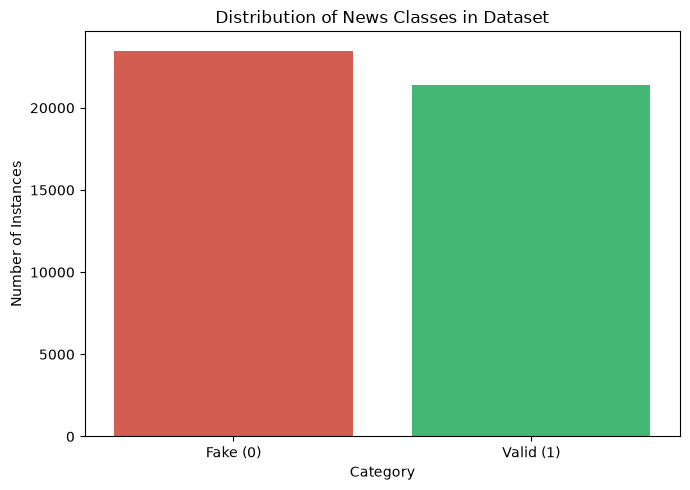

In [ ]:
# =====================================================================
# 1. PENGUMPULAN DATA & EDA AWAL
# =====================================================================
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
fake_path = os.path.join(path, "Fake.csv")
true_path = os.path.join(path, "True.csv")

print("Membaca file CSV...")
df_fake = pd.read_csv(fake_path)
df_true = pd.read_csv(true_path)

df_fake['label'] = 0  # Label 0 untuk Berita Palsu
df_true['label'] = 1  # Label 1 untuk Berita Valid

# Gabungkan data dan acak urutannya
df_all = pd.concat([df_fake, df_true], ignore_index=True)
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

# --- MENAMPILKAN DATA MENTAH SEBELUM DIBERSIHKAN ---
print("=== Statistik Kumpulan Data Mentah ===")
print("Jumlah Berita Palsu (0) :", (df_all['label'] == 0).sum())
print("Jumlah Berita Valid (1) :", (df_all['label'] == 1).sum())

plt.figure(figsize=(7, 5))
# Perbaikan Warning: Menambahkan hue='label' dan legend=False
ax = sns.countplot(data=df_all, x='label', hue='label', palette=['#E74C3C', '#2ECC71'], legend=False)
plt.title('Distribution of News Classes in Dataset')
plt.xlabel('Category')
plt.ylabel('Number of Instances')

# Perbaikan Warning: Mendefinisikan xticks sebelum xticklabels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Fake (0)', 'Valid (1)'])

plt.tight_layout()
plt.savefig('distribusi_kelas_mentah.png', dpi=150, bbox_inches='tight')
plt.show()




=== PEMERIKSAAN KUALITAS DATA ===
Ditemukan data duplikat: 209
Ditemukan teks kosong: 631

Dimensi data akhir siap pakai: (44058, 5) baris (Setelah pembersihan)
Distribusi kelas setelah dibersihkan (Untuk Training SVM):
 label
0    22848
1    21210
Name: count, dtype: int64

=== Analisis Distribusi Panjang Teks ===


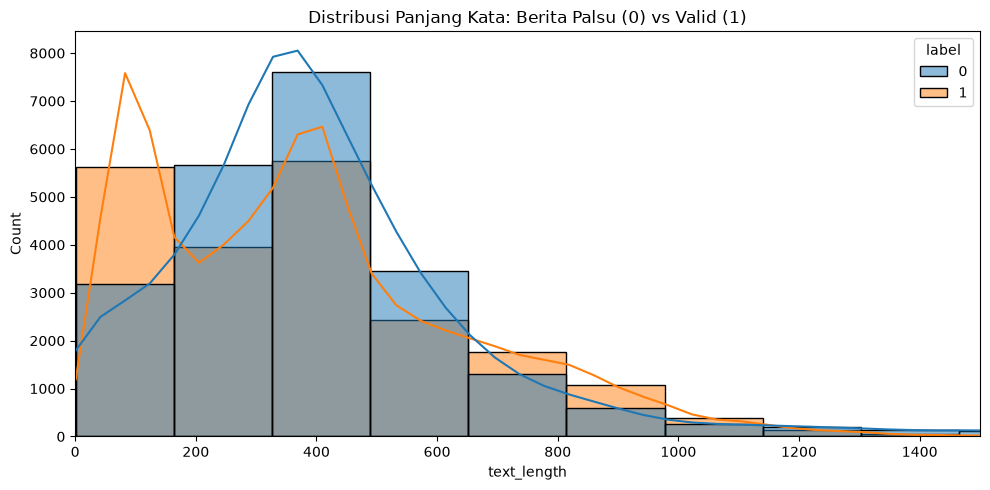

In [ ]:
# =====================================================================
# 2. PEMERIKSAAN KUALITAS & PEMBERSIHAN DATA
# =====================================================================
print("\n=== PEMERIKSAAN KUALITAS DATA ===")
n_duplikat = df_all.duplicated().sum()
n_teks_kosong = (df_all['text'].astype(str).str.strip() == '').sum()
print(f"Ditemukan data duplikat: {n_duplikat}")
print(f"Ditemukan teks kosong: {n_teks_kosong}")

# --- Eksekusi pembersihan data ---
df_all = df_all.drop_duplicates().reset_index(drop=True)
mask_teks_kosong = df_all['text'].astype(str).str.strip() == ''
n_dihapus = mask_teks_kosong.sum()
df_all = df_all[~mask_teks_kosong].reset_index(drop=True)

print(f"\nDimensi data akhir siap pakai: {df_all.shape} baris (Setelah pembersihan)")
print("Distribusi kelas setelah dibersihkan (Untuk Training SVM):\n", df_all['label'].value_counts())

# --- Distribusi Panjang Teks (Setelah dibersihkan) ---
print("\n=== Analisis Distribusi Panjang Teks ===")
df_all['text_length'] = df_all['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(data=df_all, x='text_length', hue='label', bins=50, kde=True)
plt.title('Distribusi Panjang Kata: Berita Palsu (0) vs Valid (1)')
plt.xlim(0, 1500)
plt.tight_layout()
plt.savefig('distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()


Sedang membersihkan seluruh data teks (Ini akan memakan waktu beberapa menit)...

--- Contoh 1 ---
TEKS ASLI    : 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing ...
TEKS BERSIH  : 21st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film fer ...

--- Contoh 2 ---
TEKS ASLI    : WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security  ...
TEKS BERSIH  : washington reuters u president donald trump removed chief strategist steve bannon national security council wednesday re ...


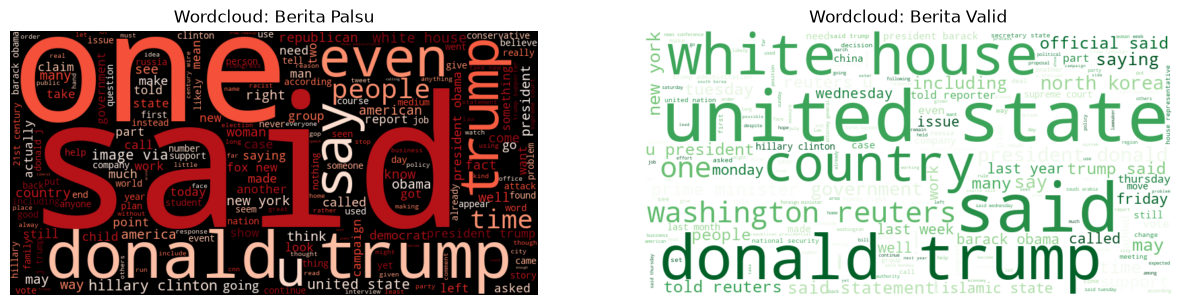


=== TOP 10 KATA - BERITA PALSU ===
trump: 73764
said: 31014
president: 26083
people: 26032
one: 23682
would: 23419
u: 22289
state: 21956
clinton: 18593
like: 18139

=== TOP 10 KATA - BERITA VALID ===
said: 97844
trump: 53752
u: 40682
state: 35954
would: 31164
reuters: 28110
president: 26707
republican: 21975
government: 19171
year: 18547

Mengekstrak data N-Gram (Bigram & Trigram)...


C:\Users\restu\AppData\Local\Temp\ipykernel_4308\3074600311.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_fake_bigram, ax=axes[0], palette='Reds_r')
C:\Users\restu\AppData\Local\Temp\ipykernel_4308\3074600311.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_valid_bigram, ax=axes[1], palette='Greens_r')


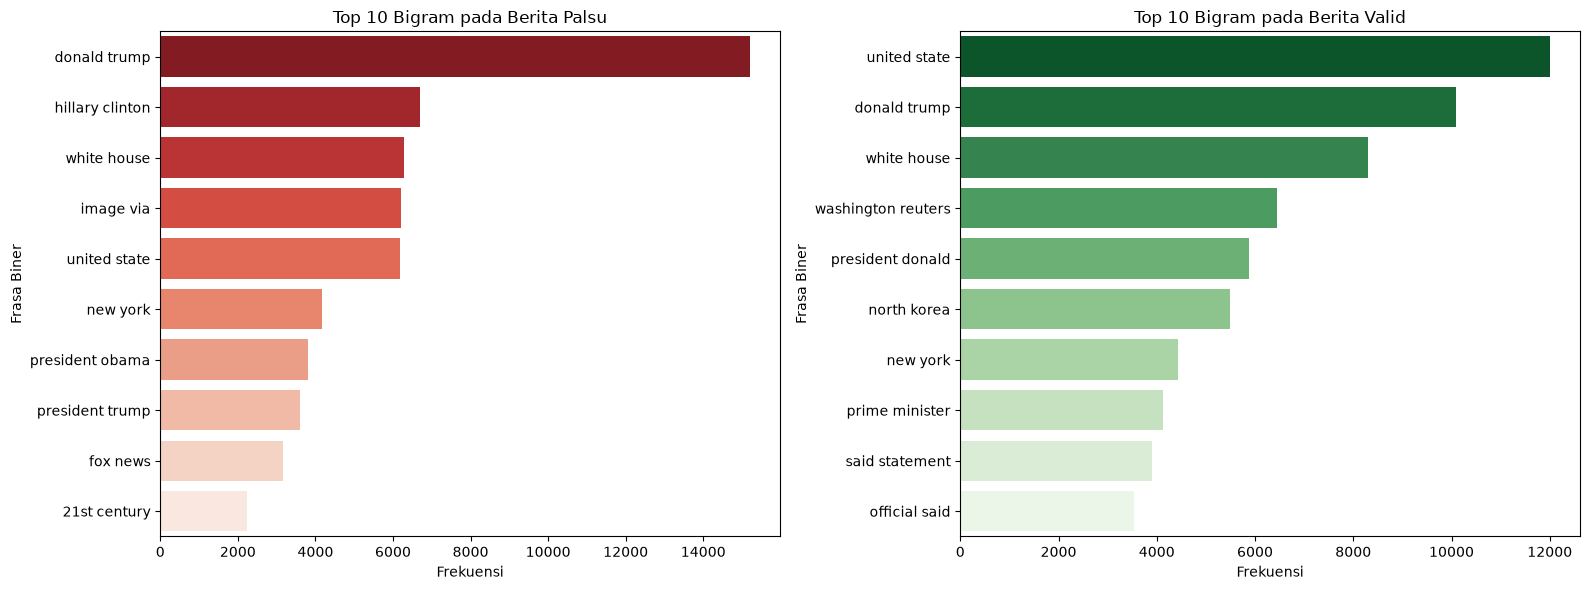

C:\Users\restu\AppData\Local\Temp\ipykernel_4308\3074600311.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_fake_trigram, ax=axes[0], palette='Reds_r')
C:\Users\restu\AppData\Local\Temp\ipykernel_4308\3074600311.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_valid_trigram, ax=axes[1], palette='Greens_r')


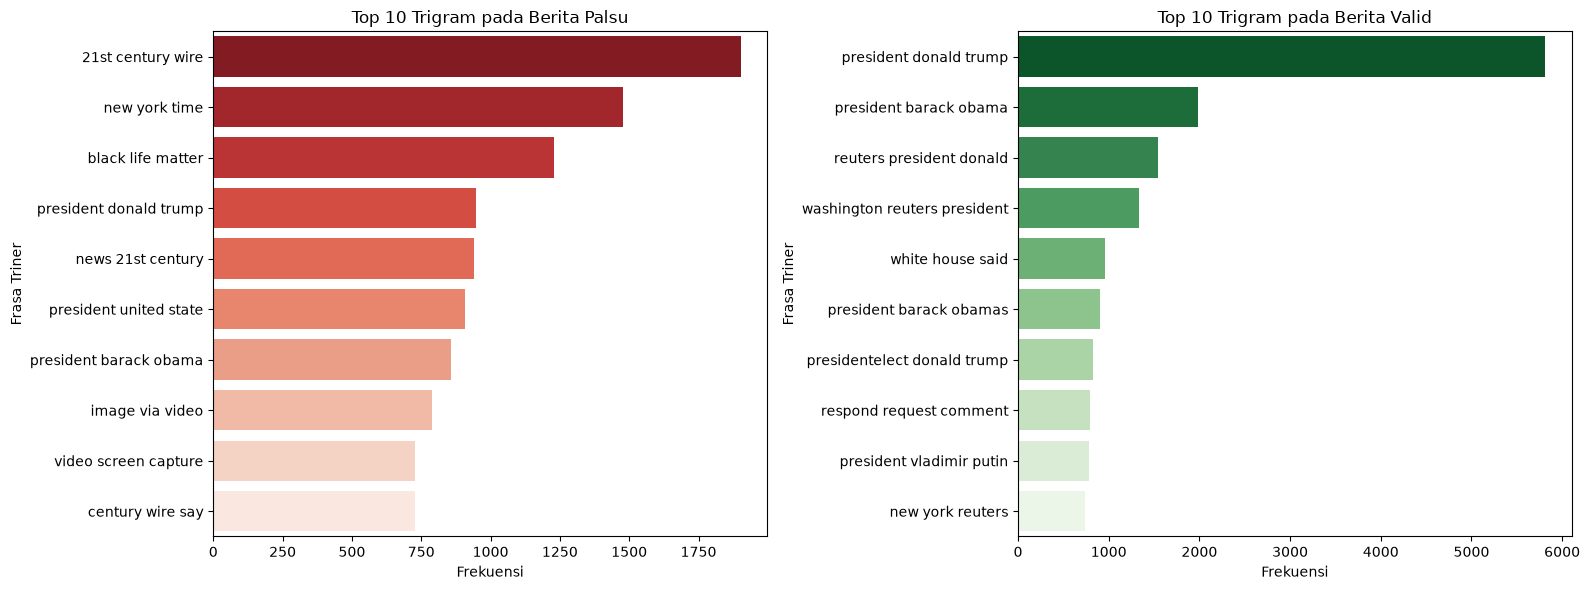


=== TOP 10 BIGRAM BERITA PALSU ===
          Frasa  Frekuensi
   donald trump      15218
hillary clinton       6689
    white house       6295
      image via       6194
   united state       6183
       new york       4181
president obama       3799
president trump       3614
       fox news       3172
   21st century       2229

=== TOP 10 BIGRAM BERITA VALID ===
             Frasa  Frekuensi
      united state      12015
      donald trump      10093
       white house       8309
washington reuters       6457
  president donald       5874
       north korea       5487
          new york       4432
    prime minister       4123
    said statement       3906
     official said       3532

=== TOP 10 TRIGRAM BERITA PALSU ===
                 Frasa  Frekuensi
     21st century wire       1902
         new york time       1478
     black life matter       1230
president donald trump        948
     news 21st century        941
president united state        907
president barack obama    

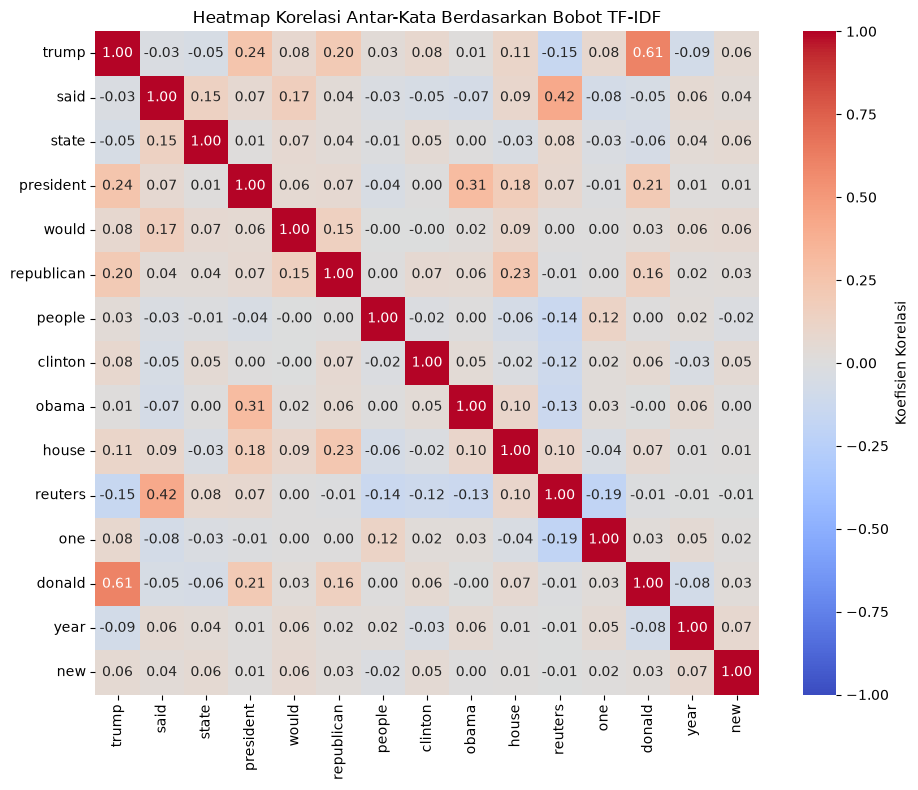


=== 5 PASANGAN KATA DENGAN KORELASI TERTINGGI ===
trump       donald       0.605389
said        reuters      0.419500
president   obama        0.308335
trump       president    0.243251
republican  house        0.232890
dtype: float64

=== 5 PASANGAN KATA DENGAN KORELASI TERENDAH (NEGATIF) ===
reuters  one       -0.187862
trump    reuters   -0.154629
people   reuters   -0.136968
obama    reuters   -0.132620
clinton  reuters   -0.115323
dtype: float64

=== STATISTIK SPARSITY MATRIKS TF-IDF ===
Dimensi matriks: 44058 dokumen x 2000 fitur
Total elemen matriks: 88,116,000
Elemen non-nol: 4,616,481
Tingkat sparsity: 94.76%
Rata-rata fitur non-nol per dokumen: 104.8


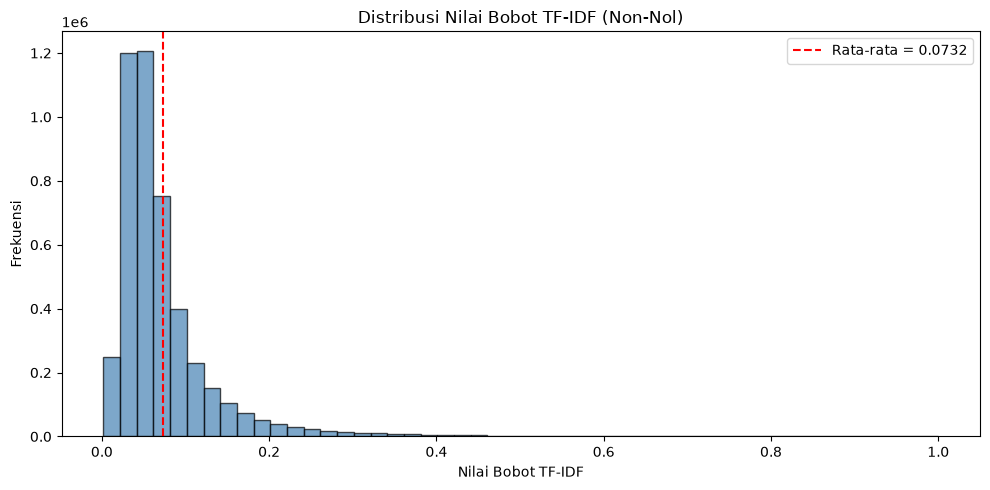

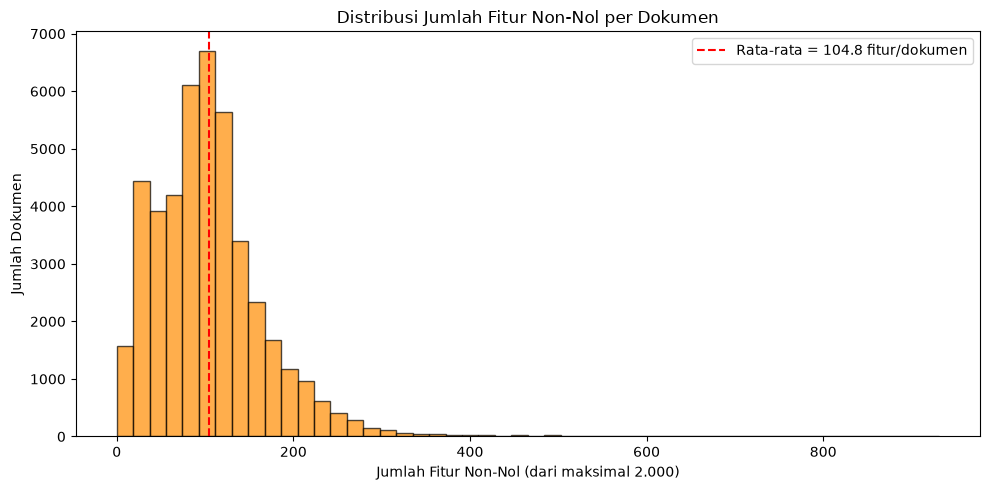


Statistik fitur non-nol per dokumen:
Minimum : 0
Maximum : 931
Median  : 98


In [4]:
# =====================================================================
# 3. PRA-PEMROSESAN DATA & EKSTRAKSI FITUR
# =====================================================================
print("\nSedang membersihkan seluruh data teks (Ini akan memakan waktu beberapa menit)...")
df_all['clean_text'] = df_all['text'].apply(clean_text)

# Intip sedikit hasil pembersihannya
for idx, row in df_all[['text', 'clean_text']].head(2).iterrows():
    print(f'\n--- Contoh {idx+1} ---')
    print('TEKS ASLI    :', row['text'][:120], '...')
    print('TEKS BERSIH  :', row['clean_text'][:120], '...')

# --- WORDCLOUD ---
fake_text = " ".join(df_all[df_all['label'] == 0]['clean_text'].astype(str))
valid_text = " ".join(df_all[df_all['label'] == 1]['clean_text'].astype(str))

plt.figure(figsize=(15,7))
plt.subplot(1, 2, 1)
wordcloud_fake = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(fake_text)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.title('Wordcloud: Berita Palsu')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_valid = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(valid_text)
plt.imshow(wordcloud_valid, interpolation='bilinear')
plt.title('Wordcloud: Berita Valid')
plt.axis('off')
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# --- TOP 10 KATA PER KELAS ---
def top_words(text_series, n=10):
    words = " ".join(text_series.astype(str)).split()
    return Counter(words).most_common(n)

print("\n=== TOP 10 KATA - BERITA PALSU ===")
for word, count in top_words(df_all[df_all['label']==0]['clean_text']):
    print(f"{word}: {count}")

print("\n=== TOP 10 KATA - BERITA VALID ===")
for word, count in top_words(df_all[df_all['label']==1]['clean_text']):
    print(f"{word}: {count}")

# --- ANALISIS N-GRAM (BIGRAM & TRIGRAM) ---
def get_top_ngram(corpus, ngram_range, n=10):
    """Fungsi pembantu untuk mengambil N-Gram teratas dari korpus"""
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:n], columns=['Frasa', 'Frekuensi'])

clean_fake_corpus = df_all[df_all['label'] == 0]['clean_text'].astype(str)
clean_valid_corpus = df_all[df_all['label'] == 1]['clean_text'].astype(str)

print("\nMengekstrak data N-Gram (Bigram & Trigram)...")
df_fake_bigram = get_top_ngram(clean_fake_corpus, (2, 2), 10)
df_valid_bigram = get_top_ngram(clean_valid_corpus, (2, 2), 10)
df_fake_trigram = get_top_ngram(clean_fake_corpus, (3, 3), 10)
df_valid_trigram = get_top_ngram(clean_valid_corpus, (3, 3), 10)

# Plot visualisasi Bigram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Frekuensi', y='Frasa', data=df_fake_bigram, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Bigram pada Berita Palsu')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Frasa Biner')

sns.barplot(x='Frekuensi', y='Frasa', data=df_valid_bigram, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Bigram pada Berita Valid')
axes[1].set_xlabel('Frekuensi')
axes[1].set_ylabel('Frasa Biner')
plt.tight_layout()
plt.savefig('distribution_bigram.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot visualisasi Trigram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Frekuensi', y='Frasa', data=df_fake_trigram, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Trigram pada Berita Palsu')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Frasa Triner')

sns.barplot(x='Frekuensi', y='Frasa', data=df_valid_trigram, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Trigram pada Berita Valid')
axes[1].set_xlabel('Frekuensi')
axes[1].set_ylabel('Frasa Triner')
plt.tight_layout()
plt.savefig('distribution_trigram.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== TOP 10 BIGRAM BERITA PALSU ===")
print(df_fake_bigram.to_string(index=False))    
print("\n=== TOP 10 BIGRAM BERITA VALID ===")
print(df_valid_bigram.to_string(index=False))
print("\n=== TOP 10 TRIGRAM BERITA PALSU ===")
print(df_fake_trigram.to_string(index=False))
print("\n=== TOP 10 TRIGRAM BERITA VALID ===")
print(df_valid_trigram.to_string(index=False))

# --- EKSTRAKSI FITUR TF-IDF ---
print("\nSedang melakukan vektorisasi TF-IDF...")
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(df_all['clean_text'])
y = df_all['label']

feature_names = tfidf.get_feature_names_out()
tfidf_means = np.asarray(X.mean(axis=0)).flatten()
top15_idx = tfidf_means.argsort()[-15:][::-1]

print("\n=== 15 KATA DENGAN BOBOT TF-IDF RATA-RATA TERTINGGI ===")
for idx in top15_idx:
    print(f"{feature_names[idx]}: {tfidf_means[idx]:.5f}")

# --- HEATMAP KORELASI TF-IDF ---
top15_words = [feature_names[idx] for idx in top15_idx]
X_top15 = X[:, top15_idx].toarray()
df_top15 = pd.DataFrame(X_top15, columns=top15_words)
corr_matrix = df_top15.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Koefisien Korelasi'})
plt.title('Heatmap Korelasi Antar-Kata Berdasarkan Bobot TF-IDF')
plt.tight_layout()
plt.savefig('tfidf_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().sort_values(ascending=False)
print("\n=== 5 PASANGAN KATA DENGAN KORELASI TERTINGGI ===")
print(corr_pairs.nlargest(5))
print("\n=== 5 PASANGAN KATA DENGAN KORELASI TERENDAH (NEGATIF) ===")
print(corr_pairs.dropna().nsmallest(5))

# --- DISTRIBUSI & SPARSITY MATRIKS TF-IDF ---
X_dense_nonzero = X.data  
total_elemen = X.shape[0] * X.shape[1]
elemen_nonzero = X.nnz
sparsity = 1 - (elemen_nonzero / total_elemen)

print("\n=== STATISTIK SPARSITY MATRIKS TF-IDF ===")
print(f"Dimensi matriks: {X.shape[0]} dokumen x {X.shape[1]} fitur")
print(f"Total elemen matriks: {total_elemen:,}")
print(f"Elemen non-nol: {elemen_nonzero:,}")
print(f"Tingkat sparsity: {sparsity*100:.2f}%")
print(f"Rata-rata fitur non-nol per dokumen: {elemen_nonzero/X.shape[0]:.1f}")

plt.figure(figsize=(10, 5))
plt.hist(X_dense_nonzero, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribusi Nilai Bobot TF-IDF (Non-Nol)')
plt.xlabel('Nilai Bobot TF-IDF')
plt.ylabel('Frekuensi')
plt.axvline(X_dense_nonzero.mean(), color='red', linestyle='--', 
            label=f'Rata-rata = {X_dense_nonzero.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('distribusi_bobot_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

nonzero_per_doc = np.diff(X.indptr) 

plt.figure(figsize=(10, 5))
plt.hist(nonzero_per_doc, bins=50, color='darkorange', edgecolor='black', alpha=0.7)
plt.title('Distribusi Jumlah Fitur Non-Nol per Dokumen')
plt.xlabel('Jumlah Fitur Non-Nol (dari maksimal 2.000)')
plt.ylabel('Jumlah Dokumen')
plt.axvline(nonzero_per_doc.mean(), color='red', linestyle='--',
            label=f'Rata-rata = {nonzero_per_doc.mean():.1f} fitur/dokumen')
plt.legend()
plt.tight_layout()
plt.savefig('distribusi_fitur_per_dokumen.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStatistik fitur non-nol per dokumen:")
print(f"Minimum : {nonzero_per_doc.min()}")
print(f"Maximum : {nonzero_per_doc.max()}")
print(f"Median  : {np.median(nonzero_per_doc):.0f}")



In [10]:
# =====================================================================
# 4. IMPLEMENTASI MODEL SVM
# =====================================================================
print("\nMembagi himpunan data 80:20...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Mencari Hyperparameter terbaik (GridSearchCV) menggunakan subset data...")
X_train_subset = X_train[:5000]
y_train_subset = y_train[:5000]

param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale'], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=3, n_jobs=-1)

grid.fit(X_train_subset, y_train_subset)
print(f"\nHyperparameter terbaik yang ditemukan: {grid.best_params_}")

print("\n=== RIWAYAT HASIL GRIDSEARCHCV ===")
cv_results = pd.DataFrame(grid.cv_results_)
cv_results_display = cv_results[['param_C', 'param_kernel', 'param_gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']]
cv_results_display = cv_results_display.sort_values('rank_test_score')
print(cv_results_display.to_string(index=False))

print("\nSedang melatih model final dengan seluruh data latih (X_train)...")
best_svm = SVC(**grid.best_params_)
best_svm.fit(X_train, y_train)

print("Model SVM final berhasil dilatih dan dapat diuji")



Membagi himpunan data 80:20...
Mencari Hyperparameter terbaik (GridSearchCV) menggunakan subset data...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Hyperparameter terbaik yang ditemukan: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

=== RIWAYAT HASIL GRIDSEARCHCV ===
 param_C param_kernel param_gamma  mean_test_score  std_test_score  rank_test_score
    10.0          rbf       scale           0.9786        0.001715                1
     1.0          rbf       scale           0.9780        0.001569                2
     0.1          rbf       scale           0.9408        0.002426                3

Sedang melatih model final dengan seluruh data latih (X_train)...
Model SVM final berhasil dilatih dan dapat diuji



Mengevaluasi Model pada Data Uji (Testing Set)...

--- Laporan Klasifikasi (Classification Report) ---
              precision    recall  f1-score   support

    Fake (0)       0.99      1.00      1.00      4586
   Valid (1)       1.00      0.99      1.00      4226

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812



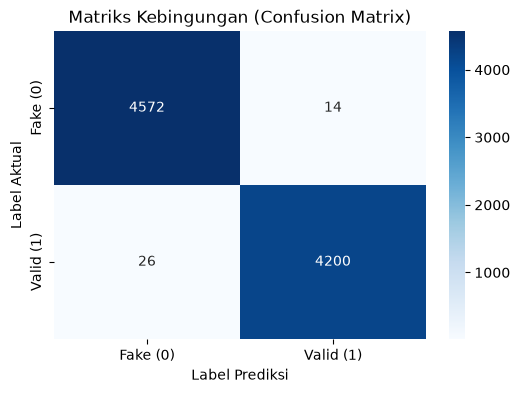


=== CONFUSION MATRIX FINAL ===
True Negative (Fake benar): 4572
False Positive (Fake→Valid): 14
False Negative (Valid→Fake): 26
True Positive (Valid benar): 4200

Total prediksi salah: 40 dari 8812 data uji
Berita Palsu yang salah diprediksi sebagai Valid (False Negative): 14
Berita Valid yang salah diprediksi sebagai Fake (False Positive): 26

=== CONTOH KASUS: Berita Palsu yang lolos (diprediksi Valid) ===

[Index 21422] Panjang teks: 255 kata
Cuplikan: U.S. Immigration and Customs Enforcement said Tuesday that a Somali refugee charged with ramming his car into a Canadian policeman, stabbing him and then injuring four people while leading officers on a high-speed chase over the weekend was ordered deported from the U.S. in 2011.Jennifer Elzea, an I...

[Index 1616] Panjang teks: 156 kata
Cuplikan: Several attendees left Republican presidential nominee Donald Trump s Saturday rally in Bangor to find their parked cars vandalized with white spray paint.A Bangor police spokesman said of

In [12]:
# =====================================================================
# 5. EVALUASI KINERJA & ERROR ANALYSIS
# =====================================================================
print("\nMengevaluasi Model pada Data Uji (Testing Set)...")
y_pred = best_svm.predict(X_test)

print("\n--- Laporan Klasifikasi (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Valid (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake (0)', 'Valid (1)'], yticklabels=['Fake (0)', 'Valid (1)'])
plt.title('Matriks Kebingungan (Confusion Matrix)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.show()

print(f"\n=== CONFUSION MATRIX FINAL ===")
print(f"True Negative (Fake benar): {cm[0][0]}")
print(f"False Positive (Fake→Valid): {cm[0][1]}")
print(f"False Negative (Valid→Fake): {cm[1][0]}")
print(f"True Positive (Valid benar): {cm[1][1]}")

# --- ANALISIS ERROR (PREDIKSI SALAH) ---
test_indices = y_test.index

results_df = pd.DataFrame({
    'index': test_indices,
    'actual': y_test.values,
    'predicted': y_pred
})

errors_df = results_df[results_df['actual'] != results_df['predicted']]
print(f"\nTotal prediksi salah: {len(errors_df)} dari {len(results_df)} data uji")

false_negative = errors_df[(errors_df['actual'] == 0) & (errors_df['predicted'] == 1)]
false_positive = errors_df[(errors_df['actual'] == 1) & (errors_df['predicted'] == 0)]

print(f"Berita Palsu yang salah diprediksi sebagai Valid (False Negative): {len(false_negative)}")
print(f"Berita Valid yang salah diprediksi sebagai Fake (False Positive): {len(false_positive)}")

print("\n=== CONTOH KASUS: Berita Palsu yang lolos (diprediksi Valid) ===")
for idx in false_negative['index'].head(3):
    original_text = df_all.loc[idx, 'text']
    print(f"\n[Index {idx}] Panjang teks: {len(str(original_text).split())} kata")
    print(f"Cuplikan: {str(original_text)[:300]}...")

print("\n=== CONTOH KASUS: Berita Valid yang salah ditebak sebagai Palsu ===")
for idx in false_positive['index'].head(3):
    original_text = df_all.loc[idx, 'text']
    print(f"\n[Index {idx}] Panjang teks: {len(str(original_text).split())} kata")
    print(f"Cuplikan: {str(original_text)[:300]}...")

print("\n=== ANALISIS DETAIL: Berita Palsu yang Lolos (False Negative) ===")
for idx in false_negative['index'].head(5):
    original_text = df_all.loc[idx, 'text']
    
    print(f"--- Index {idx} ---")
    print(f"Judul/awal teks asli: {str(original_text)[:150]}")
    print(f"Apakah mengandung 'Reuters': {'Reuters' in str(original_text)}")
    print(f"Apakah mengandung format kota+kurung (ex: WASHINGTON (Reuters)): {bool(re.search(r'[A-Z]{2,}\s*\(', str(original_text)[:50]))}")
    print(f"Panjang teks (kata): {len(str(original_text).split())}\n")

# --- PERBANDINGAN PANJANG TEKS (DILUSI FITUR) ---
print("=== PERBANDINGAN PANJANG TEKS ===")
fn_lengths = [len(str(df_all.loc[idx, 'text']).split()) for idx in false_negative['index']]
fp_lengths = [len(str(df_all.loc[idx, 'text']).split()) for idx in false_positive['index']]

print(f"Rata-rata panjang teks False Negative (Fake→Valid): {sum(fn_lengths)/len(fn_lengths):.1f} kata")
print(f"Rata-rata panjang teks False Positive (Valid→Fake): {sum(fp_lengths)/len(fp_lengths):.1f} kata")
print(f"Rata-rata panjang teks keseluruhan data uji: {df_all.loc[test_indices, 'text_length'].mean():.1f} kata")

# --- CEK PROPORSIONAL ARTEFAK 'REUTERS' ---
fn_texts = [str(df_all.loc[idx, 'text']) for idx in false_negative['index']]
fn_with_reuters = sum('Reuters' in t for t in fn_texts)
print(f"\nDari {len(fn_texts)} kasus False Negative, {fn_with_reuters} di antaranya mengandung kata 'Reuters'")

fp_texts = [str(df_all.loc[idx, 'text']) for idx in false_positive['index']]
fp_with_reuters = sum('Reuters' in t for t in fp_texts)
print(f"Dari {len(fp_texts)} kasus False Positive, {fp_with_reuters} di antaranya mengandung kata 'Reuters'")